# FASE 1: Preprocesamiento y NLP

**Autor:** Jaime Meléndez Zambrano

## Objetivo
Aplicar técnicas de NLP (normalización, tokenización, eliminación de
stopwords, stemming y vectorización TF-IDF) para limpiar y preparar las
respuestas de estudiantes para las fases de clasificación, clustering y
generación.

Se usa la clase `ProcesadorNLP` (`src/procesador_nlp.py`), que carga el
corpus ya etiquetado en la Fase 0 desde `data/corpus_etiquetado/<categoria>/`
(843 textos, provenientes de los 12 encuestadores).

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../src'))
from procesador_nlp import ProcesadorNLP


## Cargar el corpus

In [2]:
procesador = ProcesadorNLP(idioma='spanish')
textos, etiquetas = procesador.cargar_corpus('../data/corpus_etiquetado')


Corpus cargado: 843 textos
Categorías: ['desagradable', 'mixto', 'placentero']


## Observar el texto original antes de procesar

In [3]:
for i in [0, 1, 2]:
    print(f"--- RESPUESTA {i+1} (categoría: {etiquetas[i]}) ---")
    print(textos[i])
    print()


--- RESPUESTA 1 (categoría: desagradable) ---
a veces me siento agotada porque me acuesto tarde estudiando y en el colegio me da sueño, pero en la casa trato de organizar mi tiempo libre.

--- RESPUESTA 2 (categoría: desagradable) ---
me siento alegre en el colegio por estar con mis amigos, pero en casa a veces me aburro un poco si no tengo planes o si hay mucho por hacer.

--- RESPUESTA 3 (categoría: desagradable) ---
a veces frustrado porque siento que pasamos casi todo el día enfocados en el colegio y en la casa el tiempo libre se va rápido en deberes.



## Pipeline de limpieza paso a paso (sobre un ejemplo)

In [4]:
ejemplo = textos[0]
print("ORIGINAL:")
print(ejemplo)

limpio = procesador.limpiar_texto(ejemplo)
print("\nMINÚSCULAS + SIN PUNTUACIÓN/NÚMEROS:")
print(limpio)

tokens = procesador.tokenizar(limpio)
print("\nTOKENS:")
print(tokens)

sin_stop = procesador.eliminar_stopwords(tokens)
print("\nSIN STOPWORDS:")
print(sin_stop)

stems = procesador.stemizar(sin_stop)
print("\nSTEMMING:")
print(stems)


ORIGINAL:
a veces me siento agotada porque me acuesto tarde estudiando y en el colegio me da sueño, pero en la casa trato de organizar mi tiempo libre.

MINÚSCULAS + SIN PUNTUACIÓN/NÚMEROS:
a veces me siento agotada porque me acuesto tarde estudiando y en el colegio me da sueño pero en la casa trato de organizar mi tiempo libre

TOKENS:
['a', 'veces', 'me', 'siento', 'agotada', 'porque', 'me', 'acuesto', 'tarde', 'estudiando', 'y', 'en', 'el', 'colegio', 'me', 'da', 'sueño', 'pero', 'en', 'la', 'casa', 'trato', 'de', 'organizar', 'mi', 'tiempo', 'libre']

SIN STOPWORDS:
['veces', 'siento', 'agotada', 'acuesto', 'tarde', 'estudiando', 'colegio', 'da', 'sueño', 'casa', 'trato', 'organizar', 'tiempo', 'libre']

STEMMING:
['vec', 'sient', 'agot', 'acuest', 'tard', 'estudi', 'colegi', 'da', 'sueñ', 'cas', 'trat', 'organiz', 'tiemp', 'libr']


### Nota sobre stopwords y tildes

Al limpiar el texto se conservan las tildes y la `ñ` (`[^\w\sáéíóúüñ]`)
en vez de eliminarlas, porque NLTK distingue `como` de `cómo` y `si` de
`sí`, y varias stopwords en español llevan tilde (`más`, `también`,
`está`, etc.). Quitar las tildes antes de comparar contra la lista de
stopwords haría que palabras como `más` no se reconocieran como
stopword.

## Estadísticas del corpus completo

In [5]:
stats_df = procesador.analizar_corpus()
stats_df.head()


,id,categoria,palabras_originales,tokens,tokens_sin_stopwords,palabras_unicas
0,texto_0012,desagradable,27,29,16,16
1,texto_0013,desagradable,30,32,13,12
2,texto_0025,desagradable,27,28,15,15
3,texto_0035,desagradable,24,25,14,13
4,texto_0036,desagradable,20,22,11,11


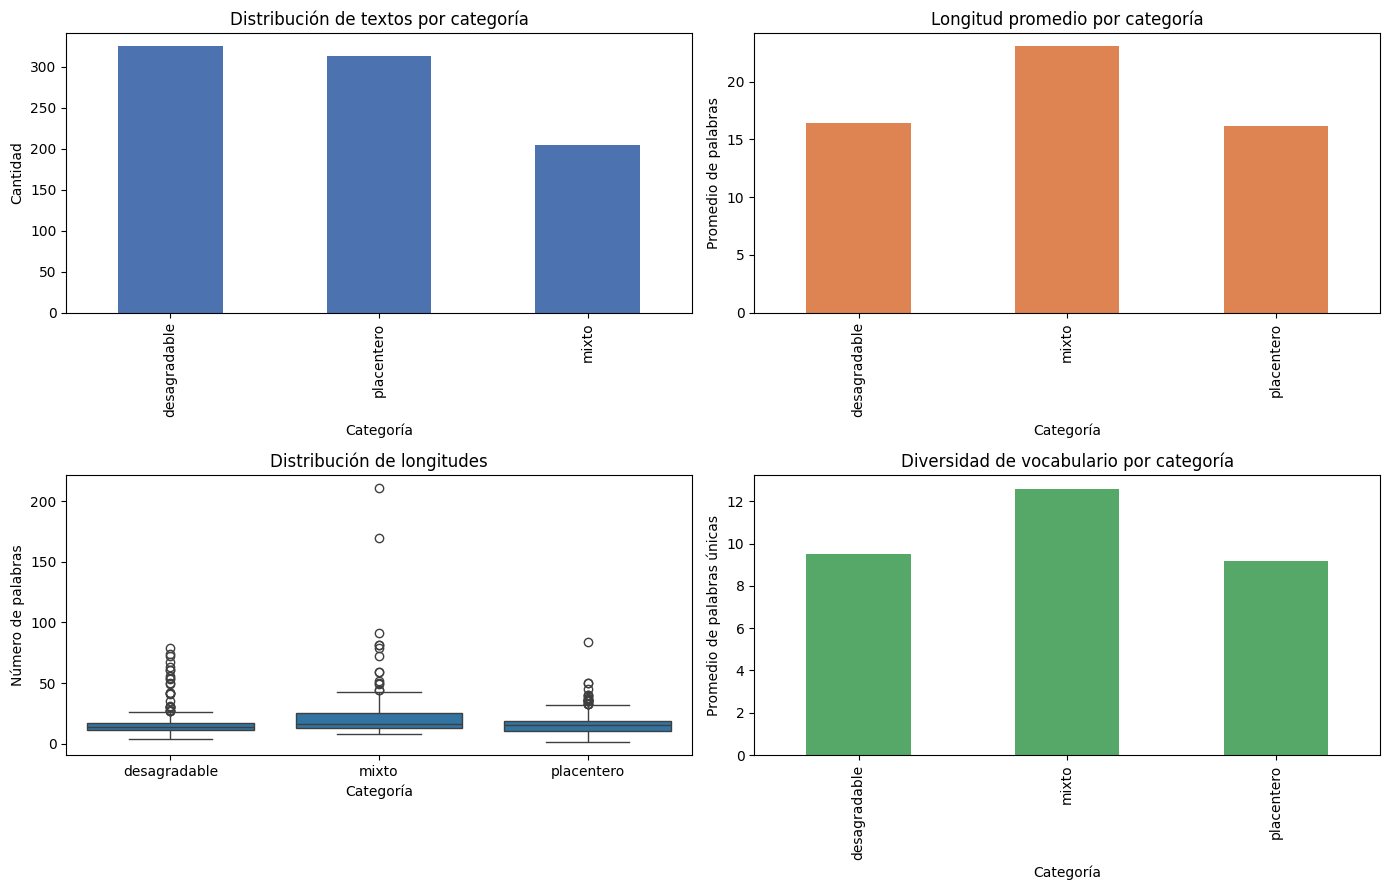

In [6]:
fig = procesador.visualizar_stats()
plt.show()


## Tabla comparativa de estadísticas generales

In [7]:
estadisticas_generales = pd.DataFrame({
    "Estadística": [
        "Total textos", "Total categorías", "Promedio palabras",
        "Promedio tokens", "Mayor longitud", "Menor longitud",
    ],
    "Tu Corpus": [
        len(stats_df),
        stats_df['categoria'].nunique(),
        round(stats_df['palabras_originales'].mean(), 2),
        round(stats_df['tokens'].mean(), 2),
        stats_df['palabras_originales'].max(),
        stats_df['palabras_originales'].min(),
    ],
    "Corpus Ejemplo (guía)": [43, 4, "-", "-", "-", "-"],
})
estadisticas_generales


,Estadística,Tu Corpus,Corpus Ejemplo (guía)
0,Total textos,843.00,43
1,Total categorías,3.00,4
2,Promedio palabras,17.92,-
3,Promedio tokens,19.34,-
4,Mayor longitud,211.00,-
5,Menor longitud,1.00,-


## Análisis detallado por categoría (con las 5 palabras más frecuentes, sin stopwords)

In [8]:
from collections import Counter

resumen_categoria = []
for categoria in sorted(set(etiquetas)):
    idx_categoria = [i for i, e in enumerate(etiquetas) if e == categoria]
    contador = Counter()
    for i in idx_categoria:
        tokens_i = procesador.eliminar_stopwords(procesador.tokenizar(textos[i]))
        contador.update([t.lower() for t in tokens_i if t.isalpha()])
    top5 = [p for p, _ in contador.most_common(5)]

    sub = stats_df[stats_df['categoria'] == categoria]
    resumen_categoria.append({
        "Categoría": categoria,
        "# Textos": len(sub),
        "Promedio Palabras": round(sub['palabras_originales'].mean(), 2),
        "Promedio Tokens": round(sub['tokens'].mean(), 2),
        "Promedio Palabras Únicas": round(sub['palabras_unicas'].mean(), 2),
        "Top 5 Palabras": ", ".join(top5),
    })

tabla_categorias = pd.DataFrame(resumen_categoria)
tabla_categorias


,Categoría,# Textos,Promedio Palabras,Promedio Tokens,Promedio Palabras Únicas,Top 5 Palabras
0,desagradable,325,16.41,17.70,9.49,"tiempo, siento, tareas, veces, libre"
1,mixto,205,23.07,25.09,12.60,"tiempo, siento, bien, casa, tareas"
2,placentero,313,16.13,17.27,9.16,"bien, tiempo, siento, casa, colegio"


## Vectorización TF-IDF (preparación para las siguientes fases)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stopwords_es = list(stopwords.words('spanish'))
vectorizador = TfidfVectorizer(max_features=2000, stop_words=stopwords_es, ngram_range=(1, 2))
X_tfidf = vectorizador.fit_transform(textos)

print("Número de documentos:", X_tfidf.shape[0])
print("Número de características:", X_tfidf.shape[1])
print("Vocabulario unigrama+bigrama total (sin recortar):",
      len(TfidfVectorizer(stop_words=stopwords_es, ngram_range=(1, 2)).fit(textos).vocabulary_))


Número de documentos: 843
Número de características: 2000
Vocabulario unigrama+bigrama total (sin recortar): 5130


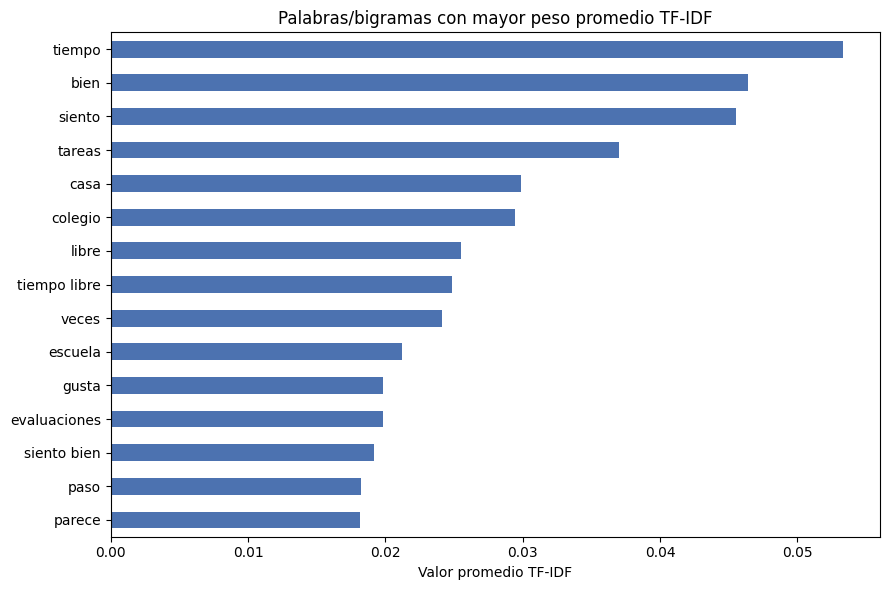

In [10]:
import numpy as np

caracteristicas = vectorizador.get_feature_names_out()
promedio_tfidf = pd.Series(np.asarray(X_tfidf.mean(axis=0)).ravel(), index=caracteristicas)
top_tfidf = promedio_tfidf.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
top_tfidf.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Palabras/bigramas con mayor peso promedio TF-IDF')
plt.xlabel('Valor promedio TF-IDF')
plt.tight_layout()
plt.show()


## Reflexión de la Fase 1

**¿Qué desafíos encontraste al procesar tu corpus?**
Con 12 encuestadores el desafío cambió de naturaleza respecto a la versión
anterior (un solo encuestador): ya no es solo el tamaño desigual de las
respuestas, sino la **variedad de registros de escritura** — desde respuestas
muy formales ("Considero que...", "Estoy conforme con...") hasta muy
coloquiales y con errores de tipeo ("no se con fljera y con sueño..."). El
pipeline de limpieza (minúsculas, sin puntuación, conservando tildes/ñ) es
razonablemente robusto a eso, pero el stemming trata "aja" o "ps" como
tokens válidos igual que cualquier palabra — no los filtra ni los reconoce
como muletillas.

**¿Tu idioma es compatible con NLTK? ¿Tuviste que hacer ajustes?**
Sí, el corpus está en español y NLTK lo soporta bien mediante
`stopwords.words('spanish')` y `SnowballStemmer('spanish')`. El único
ajuste necesario fue preservar tildes y la `ñ` al limpiar el texto (ver
nota más arriba), ya que una limpieza más agresiva (solo `[a-z]`) habría
roto el reconocimiento de varias stopwords en español.

**¿Qué diferencias notables encuentras entre tus categorías?**
Con el corpus ampliado, "mixto" pasó a ser la categoría con las respuestas
**más largas en promedio** (supera a "placentero" y "desagradable"): tiene
sentido, porque para que un texto tenga evidencia positiva Y negativa a la
vez normalmente necesita más palabras que una respuesta de una sola
polaridad. Las respuestas "placenteras" siguen mencionando `bien`, `gusta`,
`tranquilo`, mientras que las "desagradables" mencionan `tiempo`, `tareas`,
`siento` y palabras relacionadas con la carga académica. Las respuestas
"mixtas" comparten vocabulario de ambos grupos, frecuentemente unidas por
la palabra "pero", lo que confirma que la categoría mixta captura un
patrón lingüístico real y no solo un artefacto del etiquetado.